<a href="https://colab.research.google.com/github/faseeh-quraishi/Assignment1_StatisticalLearning/blob/Main/Semi-Supervised-Feature-Selection-for-Imbalanced-Tabular-Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Required installations**

In [ ]:
pip install ucimlrepo


In [ ]:
pip install imbalanced-learn

## **Importing Libraries**

In [ ]:
# === Imports ===
import os
import gc
import glob
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from ucimlrepo import fetch_ucirepo

# Preprocessing & split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Semi-supervised
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier

# Feature selection
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

# Imbalanced sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Models & metrics
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

In [ ]:
# === Drive & cache dir ===
drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/credit_cache"
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === Cache helper ===
def save_or_load(filename, generator_func, save_format="csv", force_reload=False):
    """
    General caching mechanism:
    - If the file exists and recomputation is not forced: load directly
    - Otherwise call generator_func to generate and save
    """
    path = os.path.join(SAVE_DIR, filename)

    if os.path.exists(path) and not force_reload:
        print(f"Loaded cached file: {filename}")
        if save_format == "csv":
            return pd.read_csv(path)
        elif save_format == "npy":
            return np.load(path, allow_pickle=True)
    else:
        print(f"Generating and saving: {filename}")
        result = generator_func()
        if save_format == "csv":
            result.to_csv(path, index=False)
        elif save_format == "npy":
            np.save(path, result)
        gc.collect()
        return result

## **Step 1: Data Collection & Loading**

In [ ]:
# All feature column names
columnsName = [f"X{i}" for i in range(1, 24)]

def load_data():
    data = fetch_ucirepo(id=350)
    features = data.data.features
    targets = data.data.targets
    df = pd.concat([features, targets], axis=1)
    df.rename(columns={"default payment next month": "Y"}, inplace=True)
    return df

df = save_or_load("step1_raw_data.csv", load_data)


Generating and saving: step1_raw_data.csv


In [ ]:
print(df.shape)

(30000, 24)


In [ ]:
print(df.columns)

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'Y'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

In [ ]:
print(df.describe())

                   X1            X2            X3            X4            X5  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.853133      1.551867     35.485500   
std     129747.661567      0.489129      0.790349      0.521970      9.217904   
min      10000.000000      1.000000      0.000000      0.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      6.000000      3.000000     79.000000   

                 X6            X7            X8            X9           X10  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        1.123802      1.197186

In [ ]:
print(df.isnull().sum())

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64


In [ ]:
print(df["Y"].value_counts(normalize=True))

Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## **Step 2 : Exploratory Data Analysis (EDA)**

In [ ]:
# Use cached raw data
df = save_or_load("step1_raw_data.csv", load_data)


Loaded cached file: step1_raw_data.csv


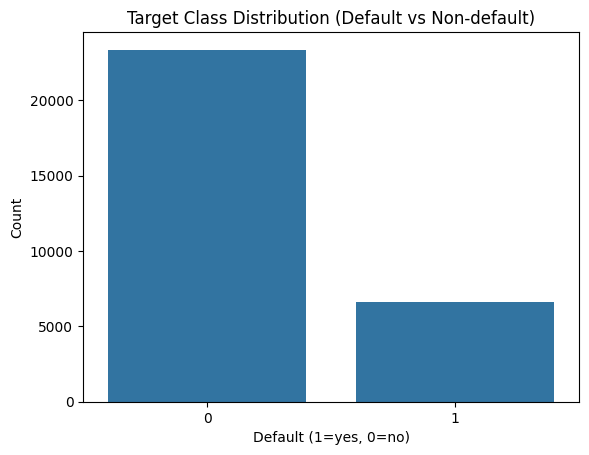

In [ ]:

# Target distribution
sns.countplot(x="Y", data=df[["Y"]])
plt.title("Target Class Distribution (Default vs Non-default)")
plt.xlabel("Default (1=yes, 0=no)")
plt.ylabel("Count")
plt.show()

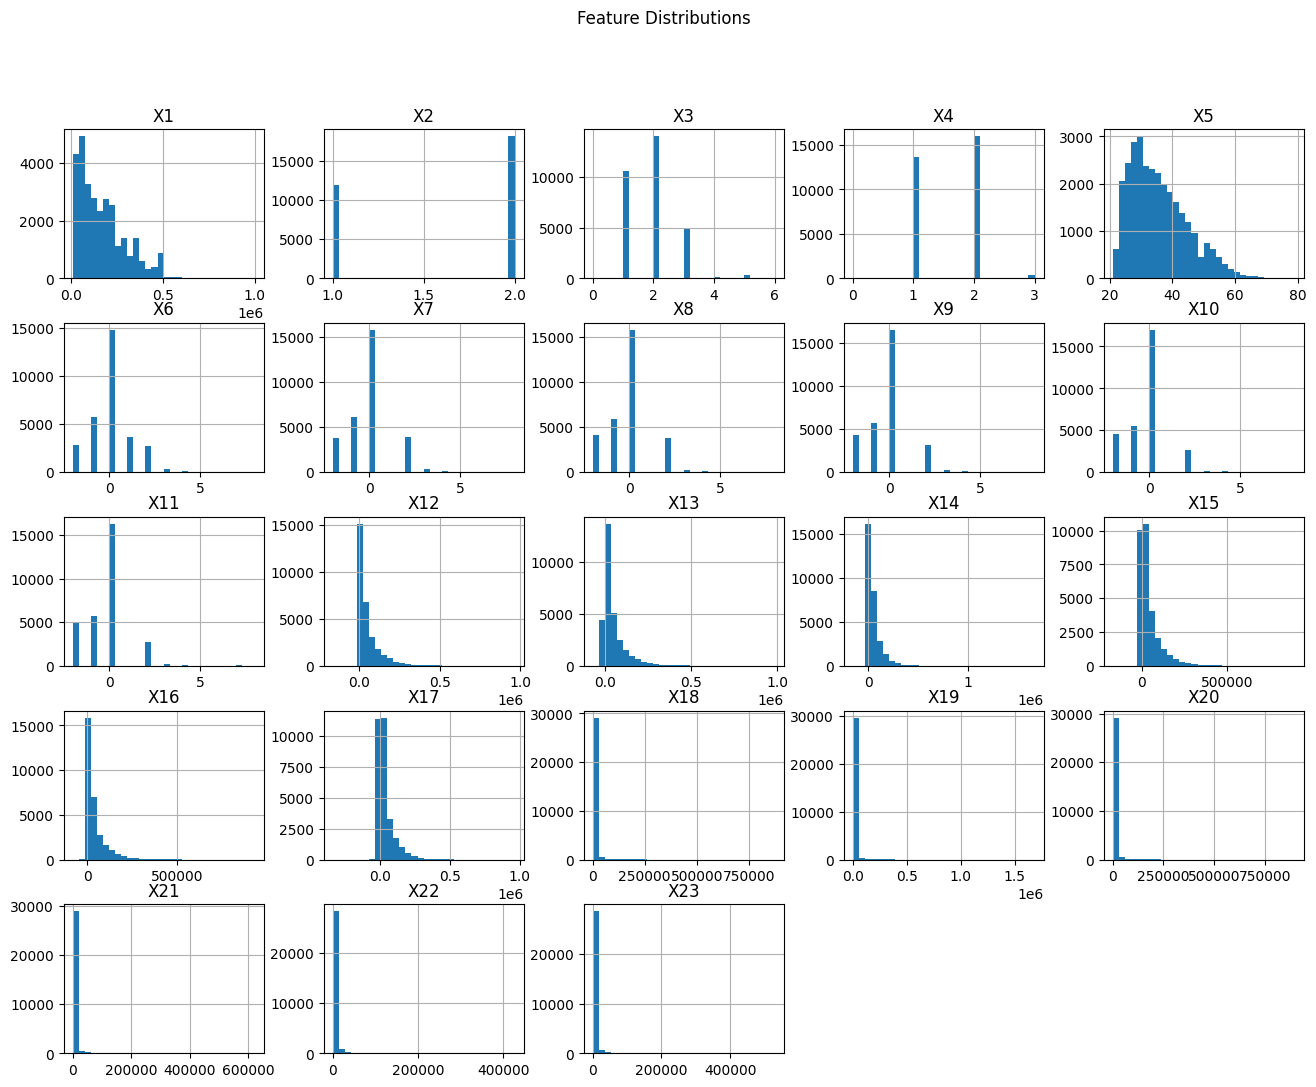

In [ ]:
# Feature histograms
df[columnsName].hist(figsize=(16, 12), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

In [ ]:
# Distribution of some categorical variables
for col in ["X2", "X3", "X4"]:
    print(col, df[col].value_counts(), "\n")

X2 X2
2    18112
1    11888
Name: count, dtype: int64 

X3 X3
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64 

X4 X4
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64 



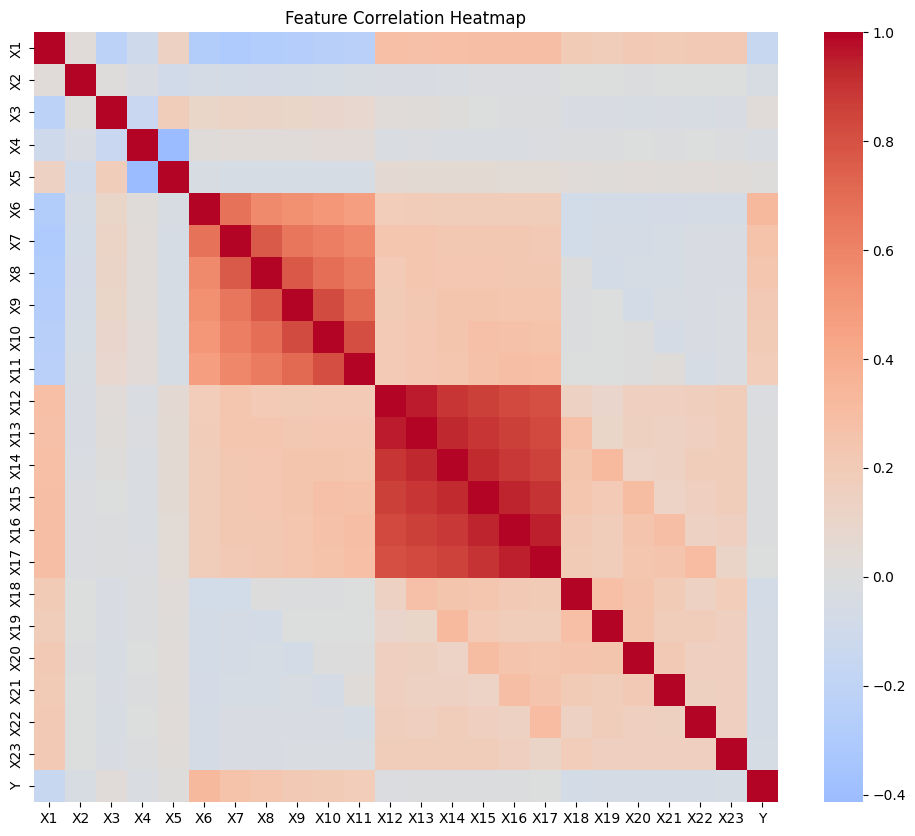

In [ ]:

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

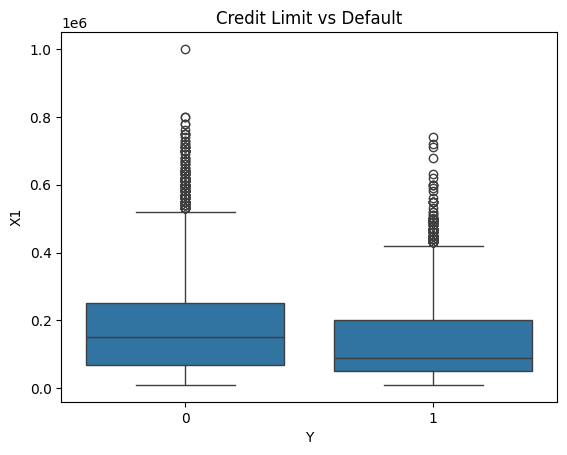

In [ ]:
# Some boxplots
sns.boxplot(x="Y", y="X1", data=df)
plt.title("Credit Limit vs Default")
plt.show()

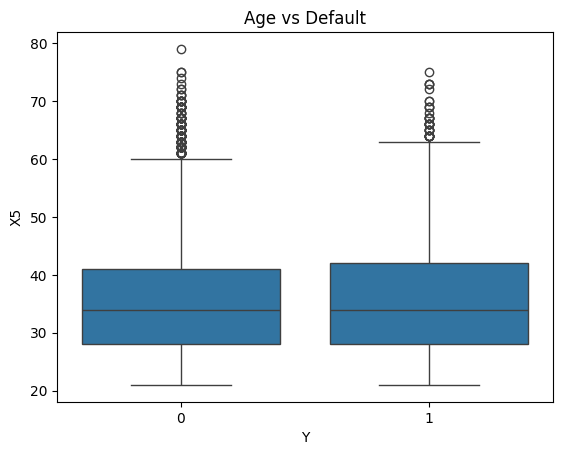

In [ ]:
sns.boxplot(x="Y", y="X5", data=df)
plt.title("Age vs Default")
plt.show()

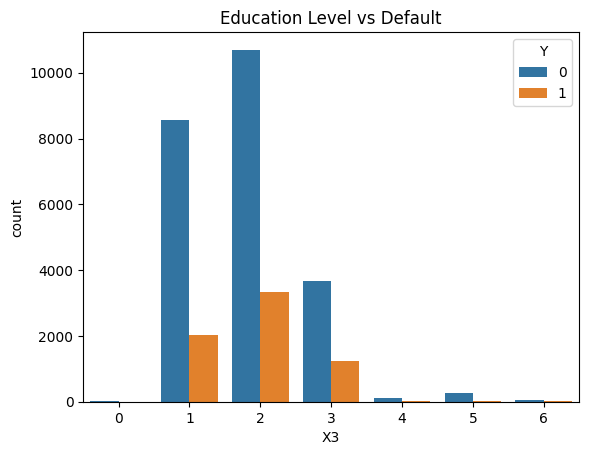

In [ ]:
sns.countplot(x="X3", hue="Y", data=df)
plt.title("Education Level vs Default")
plt.show()

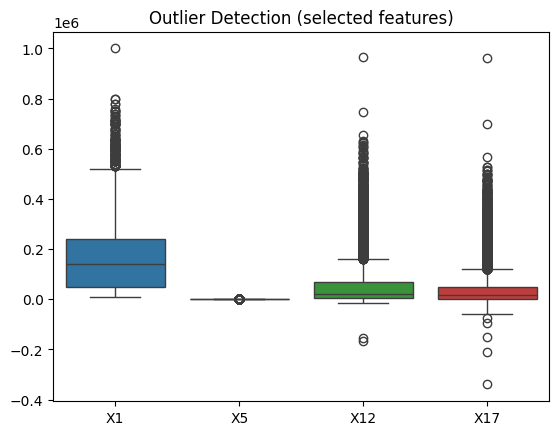

In [ ]:
sns.boxplot(data=df[["X1", "X5", "X12", "X17"]])
plt.title("Outlier Detection (selected features)")
plt.show()

## **Step 3: Data Preprocessing**

In [ ]:
# Category merging
df["X3"] = df["X3"].replace({0: 4, 5: 4, 6: 4})
df["X4"] = df["X4"].replace({0: 3})

In [ ]:
# Bill & repayment amount clipping
bill_features = ["X12", "X13", "X14", "X15", "X16", "X17"]
pay_features = ["X18", "X19", "X20", "X21", "X22", "X23"]

df[bill_features] = df[bill_features].clip(lower=0)
df[pay_features] = df[pay_features].clip(lower=0)

In [ ]:
# Standardization
scaler = StandardScaler()
features_scaled = df[columnsName].copy()
scale_cols = bill_features + pay_features + ["X1", "X5"]
features_scaled[scale_cols] = scaler.fit_transform(features_scaled[scale_cols])

In [ ]:
def save_split_before_simulation():
    X = features_scaled.copy()
    y = df["Y"].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }

split_data_before_sim = save_or_load(
    "step3_preprocessed.npy", save_split_before_simulation, save_format="npy"
).item()

X_train = split_data_before_sim["X_train"]
X_test = split_data_before_sim["X_test"]
y_train = split_data_before_sim["y_train"]
y_test = split_data_before_sim["y_test"]

print("Data before simulation saved as step3_preprocessed.npy")
print("Train:", X_train.shape, "Test:", X_test.shape)

Loaded cached file: step3_preprocessed.npy
Data before simulation saved as step3_preprocessed.npy
Train: (24000, 23) Test: (6000, 23)


In [ ]:
# —— Simulate unlabeled samples (-1) ——
def make_simulated_data():
    y_semi = y_train.copy()
    rng = np.random.RandomState(42)
    mask = rng.rand(len(y_semi)) < 0.7  # 70% become -1
    y_semi[mask] = -1

    df_sim = X_train.copy()
    df_sim["Y"] = y_semi
    df_sim["is_unlabeled"] = mask.astype(int)
    return df_sim

df_simulated = save_or_load(
    "step3_preprocessed_simulated.csv", make_simulated_data, save_format="csv", force_reload=True
)

print("Simulated training data saved as step3_preprocessed_simulated.csv")
print(df_simulated.head())
print(df_simulated["is_unlabeled"].value_counts())

Generating and saving: step3_preprocessed_simulated.csv
Simulated training data saved as step3_preprocessed_simulated.csv
             X1  X2  X3  X4        X5  X6  X7  X8  X9  X10  ...       X16  \
22788 -0.057685   2   2   2 -0.269643   2   2   3   2    0  ...  2.013210   
29006 -0.134759   2   1   2 -0.161156   1  -1  -1  -2   -2  ... -0.663979   
16950 -1.213794   1   2   1  1.574625   1   2   0   0    0  ... -0.528590   
22280  0.404759   2   1   2 -0.703588   0   0   0   0    0  ...  1.502707   
11346  1.098425   2   1   2 -0.378129   1  -2  -1   0    0  ... -0.663979   

            X17       X18       X19       X20       X21       X22       X23  \
22788  2.087018  0.563691 -0.256990 -0.296801  0.081318  0.490940  0.049755   
29006 -0.655098 -0.338742 -0.256990 -0.296801 -0.308063 -0.314136 -0.293382   
16950 -0.513791 -0.341821 -0.201392 -0.232394 -0.289296 -0.294173 -0.237130   
22280  1.604908  0.207476  0.133627  0.151154 -0.001665  0.006585  0.044129   
11346 -0.655098 -0.3

In [ ]:
def save_limited_supervised_baseline():
    df = df_simulated.copy()
    df_labeled = df[df["Y"] != -1]  # delete y=-1
    return df_labeled.drop("is_unlabeled", axis=1)

df_limited_supervised = save_or_load(
    "step3_noSemi(afterSimulate)_None_None.csv",
    save_limited_supervised_baseline,
    save_format="csv"
)

print("Step3 limited supervised baseline saved:", df_limited_supervised.shape)

Generating and saving: step3_noSemi(afterSimulate)_None_None.csv
Step3 limited supervised baseline saved: (7220, 24)


In [ ]:
def save_full_supervised_baseline():
    X = split_data_before_sim["X_train"]
    y = split_data_before_sim["y_train"]

    df_full = pd.DataFrame(X.copy())
    df_full["Y"] = y.values
    return df_full

df_full_supervised = save_or_load(
    "step3_noSemi(beforeSimulate)_None_None.csv",
    save_full_supervised_baseline,
    save_format="csv"
)

print("Step3 full supervised baseline saved:", df_full_supervised.shape)

Generating and saving: step3_noSemi(beforeSimulate)_None_None.csv
Step3 full supervised baseline saved: (24000, 24)


In [ ]:
# Clean up large unused objects
plt.close("all")
del df, features_scaled
gc.collect()

0

## **Step 4: Pseudo-Labeling for Semi-Supervised Learning**

In [ ]:
# Reload simulated data and construct y_semi
df_simulated = save_or_load(
    "step3_preprocessed_simulated.csv", make_simulated_data, save_format="csv"
)

Loaded cached file: step3_preprocessed_simulated.csv


In [ ]:
y_semi_array = df_simulated["Y"].values
mask_pseudo = (y_semi_array == -1)
print(f"Unlabeled sample ratio: {(mask_pseudo.mean()):.2%}")

Unlabeled sample ratio: 69.92%


In [ ]:
df_step4_st = pd.DataFrame({
    "pseudo_label": y_semi_array,             # 带 -1
    "is_unlabeled": mask_pseudo.astype(int),  # 1 or 0
})

df_step4_st.to_csv(os.path.join(SAVE_DIR, "step4_st.csv"), index=False)
print("Saved step4_st.csv (raw semi-supervised pseudo labels)")

Saved step4_st.csv (raw semi-supervised pseudo labels)


In [ ]:
def save_pseudo_labels(filename, pseudo_labels, mask_pseudo, model=None):
    df_save = pd.DataFrame({
        "pseudo_label": pseudo_labels,
        "is_unlabeled": mask_pseudo.astype(int),
    })

    if model is not None and hasattr(model, "label_distributions_"):
        conf = model.label_distributions_[mask_pseudo].max(axis=1)
        df_save.loc[mask_pseudo, "confidence"] = conf

    df_save.to_csv(os.path.join(SAVE_DIR, filename), index=False)
    print(f"Saved pseudo labels to {filename}")

In [ ]:
# --- LabelPropagation (RBF) ---
lp_rbf = LabelPropagation(kernel="rbf", gamma=20, max_iter=1000)
lp_rbf.fit(X_train, y_semi_array)
pseudo_labels_rbf = lp_rbf.transduction_
print("\n=== LabelPropagation (RBF) ===")
print("Number of pseudo-tags generated:", mask_pseudo.sum())
print(pd.Series(pseudo_labels_rbf[mask_pseudo]).value_counts())
if hasattr(lp_rbf, "label_distributions_"):
    conf = lp_rbf.label_distributions_[mask_pseudo].max(axis=1)
    print(f"Average confidence: {conf.mean():.4f}")

save_pseudo_labels("step4_lp_rbf.csv", pseudo_labels_rbf, mask_pseudo, lp_rbf)


=== LabelPropagation (RBF) ===
Number of pseudo-tags generated: 16780
0    13321
1     3459
Name: count, dtype: int64
Average confidence: 0.9470
Saved pseudo labels to step4_lp_rbf.csv


/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


In [ ]:
# --- LabelPropagation (KNN) ---
lp_knn = LabelPropagation(kernel="knn", n_neighbors=10, max_iter=1000)
lp_knn.fit(X_train, y_semi_array)
pseudo_labels_knn = lp_knn.transduction_
print("\n=== LabelPropagation (KNN) ===")
print(pd.Series(pseudo_labels_knn[mask_pseudo]).value_counts())
if hasattr(lp_knn, "label_distributions_"):
    conf = lp_knn.label_distributions_[mask_pseudo].max(axis=1)
    print(f"Average confidence: {conf.mean():.4f}")

save_pseudo_labels("step4_lp_knn.csv", pseudo_labels_knn, mask_pseudo, lp_knn)


=== LabelPropagation (KNN) ===
0    14439
1     2341
Name: count, dtype: int64
Average confidence: 0.8321
Saved pseudo labels to step4_lp_knn.csv


In [ ]:
# --- LabelSpreading (KNN) ---
ls_knn = LabelSpreading(kernel="knn", n_neighbors=10, alpha=0.2, max_iter=1000)
ls_knn.fit(X_train, y_semi_array)
pseudo_labels_ls = ls_knn.transduction_
print("\n=== LabelSpreading (KNN) ===")
print(pd.Series(pseudo_labels_ls[mask_pseudo]).value_counts())
if hasattr(ls_knn, "label_distributions_"):
    conf = ls_knn.label_distributions_[mask_pseudo].max(axis=1)
    print(f"Average confidence: {conf.mean():.4f}")

save_pseudo_labels("step4_ls_knn.csv", pseudo_labels_ls, mask_pseudo, ls_knn)


=== LabelSpreading (KNN) ===
0    13867
1     2913
Name: count, dtype: int64
Average confidence: 0.8628
Saved pseudo labels to step4_ls_knn.csv


In [ ]:
# === SelfTraining pseudo labels ===
print("\n=== SelfTraining(LR) ===")
base_model = LogisticRegression(max_iter=2000, random_state=42)
selftrain_model = SelfTrainingClassifier(base_model, threshold=0.8, max_iter=50)

selftrain_model.fit(X_train, y_semi_array)  # if y_semi_array contains -1
selftrain_pseudo = selftrain_model.predict(X_train)

df_selftrain = pd.DataFrame({
    "pseudo_label": selftrain_pseudo,
    "is_unlabeled": (y_semi_array == -1).astype(int)
})

df_selftrain.to_csv(os.path.join(SAVE_DIR, "step4_st_lr.csv"), index=False)

print("Saved SelfTraining pseudo labels to step4_selftraining.csv")



=== SelfTraining(LR) ===
Saved SelfTraining pseudo labels to step4_selftraining.csv


## **Step 5: Feature Selection**

In [ ]:
# Load three sets of pseudo labels
pseudo_files = {
    "LabelPropagation-RBF": os.path.join(SAVE_DIR, "step4_lp_rbf.csv"),
    "LabelPropagation-KNN": os.path.join(SAVE_DIR, "step4_lp_knn.csv"),
    "LabelSpreading-KNN": os.path.join(SAVE_DIR, "step4_ls_knn.csv"),
    "StelfTraining":os.path.join(SAVE_DIR, "step4_st_lr.csv"),
}

pseudo_label_sets = {}
for name, file in pseudo_files.items():
    df_pseudo = pd.read_csv(file)
    pseudo_label_sets[name] = df_pseudo["pseudo_label"].values
    print(f"{name} loaded, shape = {df_pseudo.shape}")

LabelPropagation-RBF loaded, shape = (24000, 3)
LabelPropagation-KNN loaded, shape = (24000, 3)
LabelSpreading-KNN loaded, shape = (24000, 3)
StelfTraining loaded, shape = (24000, 2)


In [ ]:
def select_features(X, y, method):
    """
    method: 'none' | 'l1' | 'mutualinfo'
    """
    if method == "none":
        return X.columns.tolist()

    if method == "l1":
        clf = LogisticRegression(
            penalty="l1", solver="liblinear", random_state=42, max_iter=2000
        )
        clf.fit(X, y)
        coef = np.abs(clf.coef_[0])
        top10_idx = np.argsort(coef)[-10:]
        return X.columns[top10_idx].tolist()

    if method == "mutualinfo":
        mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
        top10_idx = np.argsort(mi_scores)[-10:]
        return X.columns[top10_idx].tolist()

    raise ValueError("method must be 'none', 'l1', or 'mutualinfo'")


In [ ]:
feature_selection_results = {}
rows = []

for label_method, pseudo_labels in pseudo_label_sets.items():
    y_final = np.where(y_semi_array == -1, pseudo_labels, y_semi_array)
    feature_selection_results[label_method] = {}

    for fs_method in ["none", "l1", "mutualinfo"]:
        selected = select_features(X_train, y_final, fs_method)
        feature_selection_results[label_method][fs_method] = selected

        print(f"\n=== {label_method} | {fs_method.upper()} ===")
        print(f"Selected {len(selected)} features:")
        print(selected)

        rows.append({
            "PseudoLabel_Method": label_method,
            "FeatureSelection_Method": fs_method,
            "Num_Features": len(selected),
            "Selected_Features": selected,
        })

df_feature_summary = pd.DataFrame(rows)
print("\n=== Step 5 Feature Selection Summary ===")
display(df_feature_summary)


=== LabelPropagation-RBF | NONE ===
Selected 23 features:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

=== LabelPropagation-RBF | L1 ===
Selected 10 features:
['X2', 'X8', 'X9', 'X17', 'X7', 'X12', 'X15', 'X16', 'X19', 'X6']

=== LabelPropagation-RBF | MUTUALINFO ===
Selected 10 features:
['X1', 'X19', 'X20', 'X18', 'X11', 'X10', 'X9', 'X8', 'X7', 'X6']

=== LabelPropagation-KNN | NONE ===
Selected 23 features:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

=== LabelPropagation-KNN | L1 ===
Selected 10 features:
['X8', 'X22', 'X17', 'X9', 'X20', 'X7', 'X18', 'X12', 'X19', 'X6']

=== LabelPropagation-KNN | MUTUALINFO ===
Selected 10 features:
['X20', 'X19', 'X1', 'X18', 'X11', 'X10', 'X9', 'X8', 'X7', 'X6']

=== LabelSpreading-KNN | NONE ===
Selected 23 features:
['X1', 'X2

,PseudoLabel_Method,FeatureSelection_Method,Num_Features,Selected_Features
0,LabelPropagation-RBF,none,23,"[X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11,..."
1,LabelPropagation-RBF,l1,10,"[X2, X8, X9, X17, X7, X12, X15, X16, X19, X6]"
2,LabelPropagation-RBF,mutualinfo,10,"[X1, X19, X20, X18, X11, X10, X9, X8, X7, X6]"
3,LabelPropagation-KNN,none,23,"[X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11,..."
4,LabelPropagation-KNN,l1,10,"[X8, X22, X17, X9, X20, X7, X18, X12, X19, X6]"
5,LabelPropagation-KNN,mutualinfo,10,"[X20, X19, X1, X18, X11, X10, X9, X8, X7, X6]"
6,LabelSpreading-KNN,none,23,"[X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11,..."
7,LabelSpreading-KNN,l1,10,"[X8, X22, X13, X7, X9, X18, X14, X12, X19, X6]"
8,LabelSpreading-KNN,mutualinfo,10,"[X19, X20, X1, X18, X11, X10, X8, X9, X7, X6]"
9,StelfTraining,none,23,"[X1, X2, X3, X4, X5, X6, X7, X8, X9, X10, X11,..."


In [ ]:
# Save dictionary results & summary table
_ = save_or_load(
    "step5_feature_selection_results.csv",
    lambda: pd.DataFrame(feature_selection_results),
    save_format="csv",
    force_reload=True,
)

_ = save_or_load(
    "step5_feature_selection_summary.csv",
    lambda: df_feature_summary,
    save_format="csv",
    force_reload=True,
)

Generating and saving: step5_feature_selection_results.csv
Generating and saving: step5_feature_selection_summary.csv


## **Step 6: Imbalanced Data Handling**

In [ ]:


def handle_imbalance(X, y, method="smote"):
    if method == "smote":
        sampler = SMOTE(random_state=42)
    elif method == "under":
        sampler = RandomUnderSampler(random_state=42)
    else:
        raise ValueError("method must be 'smote' or 'under'")
    return sampler.fit_resample(X, y)


In [ ]:
imbalance_results = {}
rows_imb = []

for _, row in df_feature_summary.iterrows():
    label_method = row["PseudoLabel_Method"]
    fs_method = row["FeatureSelection_Method"]
    selected_feats = row["Selected_Features"]

    # Pseudo-label fusion
    y_final = np.where(
        y_semi_array == -1, pseudo_label_sets[label_method], y_semi_array
    )

    X_selected = X_train[selected_feats]
    print(f"\n=== {label_method} | {fs_method.upper()} ===")
    print(f"Original distribution: {Counter(y_final)}")

    imbalance_results.setdefault(label_method, {})
    imbalance_results[label_method].setdefault(fs_method, {})

    for sampler_name in ["smote", "under", "none"]:

      if sampler_name == "none":
        # no sampling
        X_res = X_selected.copy()
        y_res = y_final.copy()
      else:
        X_res, y_res = handle_imbalance(X_selected, y_final, sampler_name)

      imbalance_results[label_method][fs_method][sampler_name] = {
        "X_shape": X_res.shape,
        "y_distribution": dict(Counter(y_res)),
      }

      print(f"After {sampler_name.upper()}: {Counter(y_res)}")

      # Save resampled data (or non-resampled data)
      df_res = pd.DataFrame(
          np.column_stack((X_res, y_res)),
          columns=list(X_selected.columns) + ["Y"],
      )
      out_name = f"step6_{label_method}_{fs_method}_{sampler_name}.csv"
      df_res.to_csv(os.path.join(SAVE_DIR, out_name), index=False)

      rows_imb.append({
        "PseudoLabel_Method": label_method,
        "FeatureSelection_Method": fs_method,
        "Sampler": sampler_name.upper(),
        "X_shape": X_res.shape,
        "y_distribution": dict(Counter(y_res)),
      })


df_imbalance_summary = pd.DataFrame(rows_imb)
print("\n=== Step 6 Imbalance Summary ===\n")
display(df_imbalance_summary)


=== LabelPropagation-RBF | NONE ===
Original distribution: Counter({np.int64(0): 18946, np.int64(1): 5054})
After SMOTE: Counter({np.int64(1): 18946, np.int64(0): 18946})
After UNDER: Counter({np.int64(0): 5054, np.int64(1): 5054})
After NONE: Counter({np.int64(0): 18946, np.int64(1): 5054})

=== LabelPropagation-RBF | L1 ===
Original distribution: Counter({np.int64(0): 18946, np.int64(1): 5054})
After SMOTE: Counter({np.int64(1): 18946, np.int64(0): 18946})
After UNDER: Counter({np.int64(0): 5054, np.int64(1): 5054})
After NONE: Counter({np.int64(0): 18946, np.int64(1): 5054})

=== LabelPropagation-RBF | MUTUALINFO ===
Original distribution: Counter({np.int64(0): 18946, np.int64(1): 5054})
After SMOTE: Counter({np.int64(1): 18946, np.int64(0): 18946})
After UNDER: Counter({np.int64(0): 5054, np.int64(1): 5054})
After NONE: Counter({np.int64(0): 18946, np.int64(1): 5054})

=== LabelPropagation-KNN | NONE ===
Original distribution: Counter({np.int64(0): 20064, np.int64(1): 3936})
After

,PseudoLabel_Method,FeatureSelection_Method,Sampler,X_shape,y_distribution
0,LabelPropagation-RBF,none,SMOTE,"(37892, 23)","{1: 18946, 0: 18946}"
1,LabelPropagation-RBF,none,UNDER,"(10108, 23)","{0: 5054, 1: 5054}"
2,LabelPropagation-RBF,none,NONE,"(24000, 23)","{1: 5054, 0: 18946}"
3,LabelPropagation-RBF,l1,SMOTE,"(37892, 10)","{1: 18946, 0: 18946}"
4,LabelPropagation-RBF,l1,UNDER,"(10108, 10)","{0: 5054, 1: 5054}"
5,LabelPropagation-RBF,l1,NONE,"(24000, 10)","{1: 5054, 0: 18946}"
6,LabelPropagation-RBF,mutualinfo,SMOTE,"(37892, 10)","{1: 18946, 0: 18946}"
7,LabelPropagation-RBF,mutualinfo,UNDER,"(10108, 10)","{0: 5054, 1: 5054}"
8,LabelPropagation-RBF,mutualinfo,NONE,"(24000, 10)","{1: 5054, 0: 18946}"
9,LabelPropagation-KNN,none,SMOTE,"(40128, 23)","{1: 20064, 0: 20064}"


In [ ]:
# === Save imbalance summary to CSV ===
imbalance_csv_rows = []

for item in rows_imb:
    imbalance_csv_rows.append({
        "PseudoLabel_Method": item["PseudoLabel_Method"],
        "FeatureSelection_Method": item["FeatureSelection_Method"],
        "Sampler": item["Sampler"],
        "X_shape": str(item["X_shape"]),
        "y_distribution": str(item["y_distribution"])
    })

df_imbalance_csv = pd.DataFrame(imbalance_csv_rows)
df_imbalance_csv.to_csv(os.path.join(SAVE_DIR, "imbalance_handling.csv"), index=False)

print("\n Saved imbalance handling summary to imbalance_handling.csv")



 Saved imbalance handling summary to imbalance_handling.csv


## **Step 7: Model Training**

In [ ]:
supervised_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
    ),
}

base_lr = LogisticRegression(max_iter=2000, random_state=42)


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": auc,
    }

In [ ]:
import re

baseline_files = [
    os.path.join(SAVE_DIR, "step3_noSemi(beforeSimulate)_None_None.csv"),
    os.path.join(SAVE_DIR, "step3_noSemi(afterSimulate)_None_None.csv")
]

step6_files = glob.glob(os.path.join(SAVE_DIR, "step6_*.csv"))

all_train_files = baseline_files + step6_files
print(f"Detected {len(all_train_files)} training datasets (including baselines).")


def parse_dataset_name(filename):
    """
    Parsing the filename in step 6 yields:PseudoLabel_Method, FeatureSelection_Method, Sampler
    """

    name = os.path.basename(filename).replace(".csv", "")


    # e.g. step6_LabelPropagation-KNN_l1_smote
    pattern = r"step6_([^_]+)_([^_]+)_([^_]+)"
    match = re.match(pattern, name)

    if name.startswith("step3_noSemi(before"):
        return "NoSemi(beforeSimulate)", "none", "none"
    if name.startswith("step3_noSemi(after"):
        return "NoSemi(afterSimulate)", "none", "none"

    if match:
        pseudo = match.group(1)  # LP/LS/SelfTraining
        fs = match.group(2)      # none/l1/mutualinfo
        sampler = match.group(3) # smote/under/none
        return pseudo, fs, sampler

    return "Unknown", "Unknown", "Unknown"


model_results = []

for file in all_train_files:

    df_step = pd.read_csv(file)
    X = df_step.drop("Y", axis=1)
    y = df_step["Y"]

    dataset_name = os.path.basename(file).replace(".csv", "")
    PseudoLabel_Method, FeatureSelection_Method, Sampler = parse_dataset_name(file)


    X_test_fs = X_test[X.columns] if list(X.columns) != list(X_test.columns) else X_test

    print(f"\n=== Training on dataset: {dataset_name} ===")
    print("Parsed:", PseudoLabel_Method, FeatureSelection_Method, Sampler)
    print("Training size:", X.shape)

    # supervised only (LR / RF / XGB)
    for model_name, model in supervised_models.items():
        scores = evaluate_model(model, X, y, X_test_fs, y_test)
        model_results.append({
            "PseudoLabel_Method": PseudoLabel_Method,
            "FeatureSelection_Method": FeatureSelection_Method,
            "Sampler": Sampler,
            "Model": model_name,
            **scores
        })

df_results = pd.DataFrame(model_results)
df_results.to_csv(os.path.join(SAVE_DIR, "step7_model_results.csv"), index=False)

print("\nStep 7 training completed.")
print("Parsed results saved to step7_model_results.csv")


Detected 38 training datasets (including baselines).

=== Training on dataset: step3_noSemi(beforeSimulate)_None_None ===
Parsed: NoSemi(beforeSimulate) none none
Training size: (24000, 23)

=== Training on dataset: step3_noSemi(afterSimulate)_None_None ===
Parsed: NoSemi(afterSimulate) none none
Training size: (7220, 23)

=== Training on dataset: step6_LabelPropagation-RBF_none_smote ===
Parsed: LabelPropagation-RBF none smote
Training size: (37892, 23)

=== Training on dataset: step6_LabelPropagation-RBF_none_under ===
Parsed: LabelPropagation-RBF none under
Training size: (10108, 23)

=== Training on dataset: step6_LabelPropagation-RBF_none_none ===
Parsed: LabelPropagation-RBF none none
Training size: (24000, 23)

=== Training on dataset: step6_LabelPropagation-RBF_l1_smote ===
Parsed: LabelPropagation-RBF l1 smote
Training size: (37892, 10)

=== Training on dataset: step6_LabelPropagation-RBF_l1_under ===
Parsed: LabelPropagation-RBF l1 under
Training size: (10108, 10)

=== Traini

In [ ]:
# Save aggregated results
df_model_results = pd.DataFrame(model_results)
df_model_results.to_csv(os.path.join(SAVE_DIR, "step7_model_results.csv"), index=False)
print("Step 7 model results saved to step7_model_results.csv")
display(df_model_results)

Step 7 model results saved to step7_model_results.csv


,PseudoLabel_Method,FeatureSelection_Method,Sampler,Model,Accuracy,F1,Precision,Recall,AUC
0,NoSemi(beforeSimulate),none,none,LogisticRegression,0.808333,0.358974,0.689507,0.242653,0.707963
1,NoSemi(beforeSimulate),none,none,RandomForest,0.812000,0.460803,0.630065,0.363225,0.755017
2,NoSemi(beforeSimulate),none,none,XGBoost,0.817500,0.466634,0.659780,0.360965,0.778235
3,NoSemi(afterSimulate),none,none,LogisticRegression,0.807667,0.357461,0.684435,0.241899,0.707590
4,NoSemi(afterSimulate),none,none,RandomForest,0.812667,0.468307,0.628971,0.373022,0.750264
...,...,...,...,...,...,...,...,...,...
109,StelfTraining,mutualinfo,under,RandomForest,0.767000,0.482222,0.474144,0.490580,0.722777
110,StelfTraining,mutualinfo,under,XGBoost,0.787667,0.498425,0.521847,0.477016,0.738787
111,StelfTraining,mutualinfo,none,LogisticRegression,0.803167,0.297442,0.706215,0.188395,0.696089
112,StelfTraining,mutualinfo,none,RandomForest,0.804500,0.325474,0.686893,0.213263,0.701412


## **Step 8 Result Visualization**

In [ ]:
# Step 8: Evaluation & Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Load Step 7 results
df_results = pd.read_csv(os.path.join(SAVE_DIR, "step7_model_results.csv"))
print("Loaded model results:", df_results.shape)
display(df_results.head())


Loaded model results: (114, 9)


,PseudoLabel_Method,FeatureSelection_Method,Sampler,Model,Accuracy,F1,Precision,Recall,AUC
0,NoSemi(beforeSimulate),none,none,LogisticRegression,0.808333,0.358974,0.689507,0.242653,0.707963
1,NoSemi(beforeSimulate),none,none,RandomForest,0.812000,0.460803,0.630065,0.363225,0.755017
2,NoSemi(beforeSimulate),none,none,XGBoost,0.817500,0.466634,0.659780,0.360965,0.778235
3,NoSemi(afterSimulate),none,none,LogisticRegression,0.807667,0.357461,0.684435,0.241899,0.707590
4,NoSemi(afterSimulate),none,none,RandomForest,0.812667,0.468307,0.628971,0.373022,0.750264


In [ ]:
# Sort by AUC (descending)
df_sorted_auc = df_results.sort_values(by="AUC", ascending=False)

print("\n=== Top 10 models by AUC ===")
display(df_sorted_auc.head(10))



=== Top 10 models by AUC ===


,PseudoLabel_Method,FeatureSelection_Method,Sampler,Model,Accuracy,F1,Precision,Recall,AUC
2,NoSemi(beforeSimulate),none,none,XGBoost,0.817500,0.466634,0.659780,0.360965,0.778235
41,LabelPropagation-KNN,none,none,XGBoost,0.814333,0.475518,0.633626,0.380558,0.761964
5,NoSemi(afterSimulate),none,none,XGBoost,0.812500,0.461465,0.632546,0.363225,0.761450
38,LabelPropagation-KNN,none,under,XGBoost,0.796667,0.532925,0.541634,0.524491,0.759072
59,LabelPropagation-KNN,mutualinfo,none,XGBoost,0.812667,0.467299,0.629630,0.371515,0.758829
95,StelfTraining,none,none,XGBoost,0.806167,0.322656,0.710256,0.208742,0.758094
56,LabelPropagation-KNN,mutualinfo,under,XGBoost,0.792667,0.530566,0.531368,0.529766,0.756048
68,LabelSpreading-KNN,none,none,XGBoost,0.816167,0.476507,0.643590,0.378297,0.755947
86,LabelSpreading-KNN,mutualinfo,none,XGBoost,0.813667,0.463016,0.638411,0.363225,0.755894
83,LabelSpreading-KNN,mutualinfo,under,XGBoost,0.773500,0.521310,0.489418,0.557649,0.755166


In [ ]:
df_sorted_f1 = df_results.sort_values(by="F1", ascending=False)

print("\n=== Top 10 models by F1 ===")
display(df_sorted_f1.head(10))



=== Top 10 models by F1 ===


,PseudoLabel_Method,FeatureSelection_Method,Sampler,Model,Accuracy,F1,Precision,Recall,AUC
38,LabelPropagation-KNN,none,under,XGBoost,0.796667,0.532925,0.541634,0.524491,0.759072
56,LabelPropagation-KNN,mutualinfo,under,XGBoost,0.792667,0.530566,0.531368,0.529766,0.756048
37,LabelPropagation-KNN,none,under,RandomForest,0.792500,0.528588,0.531202,0.525998,0.752881
64,LabelSpreading-KNN,none,under,RandomForest,0.776333,0.527797,0.495050,0.565185,0.743878
47,LabelPropagation-KNN,l1,under,XGBoost,0.789667,0.526276,0.524308,0.528259,0.749198
74,LabelSpreading-KNN,l1,under,XGBoost,0.774833,0.521431,0.491979,0.554635,0.747923
83,LabelSpreading-KNN,mutualinfo,under,XGBoost,0.773500,0.521310,0.489418,0.557649,0.755166
65,LabelSpreading-KNN,none,under,XGBoost,0.771667,0.518284,0.485827,0.555388,0.753839
46,LabelPropagation-KNN,l1,under,RandomForest,0.778333,0.518116,0.498953,0.538809,0.725630
91,StelfTraining,none,under,RandomForest,0.791833,0.517947,0.530854,0.505652,0.747378


In [ ]:
df_sorted_f1 = df_results.sort_values(by="Recall", ascending=False)

print("\n=== Top 10 models by Recall ===")
display(df_sorted_f1.head(10))


=== Top 10 models by Recall ===


,PseudoLabel_Method,FeatureSelection_Method,Sampler,Model,Accuracy,F1,Precision,Recall,AUC
6,LabelPropagation-RBF,none,smote,LogisticRegression,0.697500,0.468521,0.383142,0.602864,0.704744
28,LabelPropagation-RBF,mutualinfo,under,RandomForest,0.729667,0.496586,0.422164,0.602864,0.719458
19,LabelPropagation-RBF,l1,under,RandomForest,0.727167,0.492403,0.418335,0.598342,0.720645
29,LabelPropagation-RBF,mutualinfo,under,XGBoost,0.754333,0.516087,0.457243,0.592313,0.750823
11,LabelPropagation-RBF,none,under,XGBoost,0.749333,0.506238,0.448517,0.581010,0.752175
60,LabelSpreading-KNN,none,smote,LogisticRegression,0.719667,0.478288,0.406431,0.581010,0.708211
10,LabelPropagation-RBF,none,under,RandomForest,0.747667,0.503607,0.445734,0.578749,0.737235
9,LabelPropagation-RBF,none,under,LogisticRegression,0.716833,0.473831,0.402208,0.576488,0.701947
82,LabelSpreading-KNN,mutualinfo,under,RandomForest,0.750667,0.505291,0.450206,0.575735,0.729052
15,LabelPropagation-RBF,l1,smote,LogisticRegression,0.715333,0.468905,0.399153,0.568199,0.696047


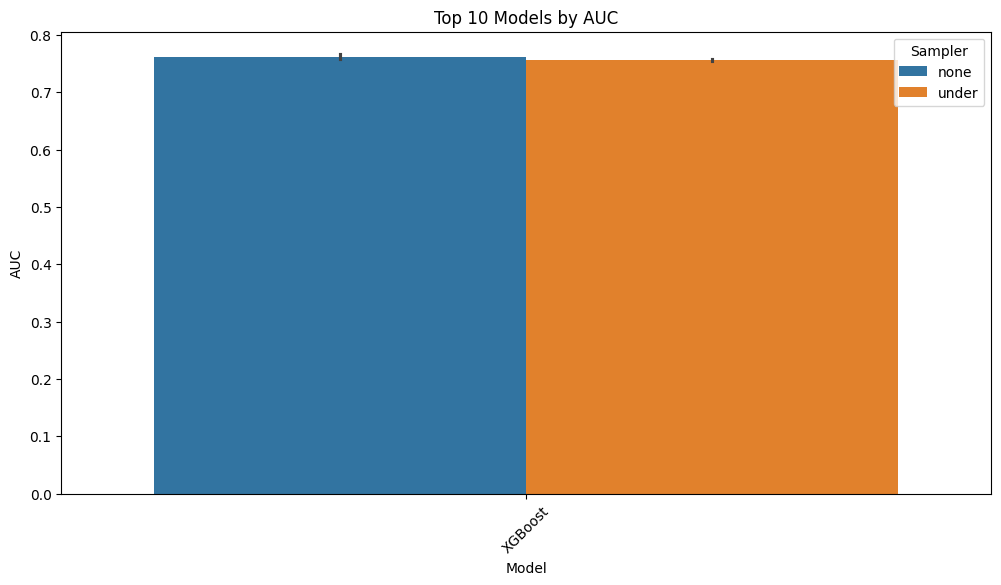

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="Model",
    y="AUC",
    data=df_sorted_auc.head(10),
    hue="Sampler"
)
plt.title("Top 10 Models by AUC")
plt.xticks(rotation=45)
plt.show()


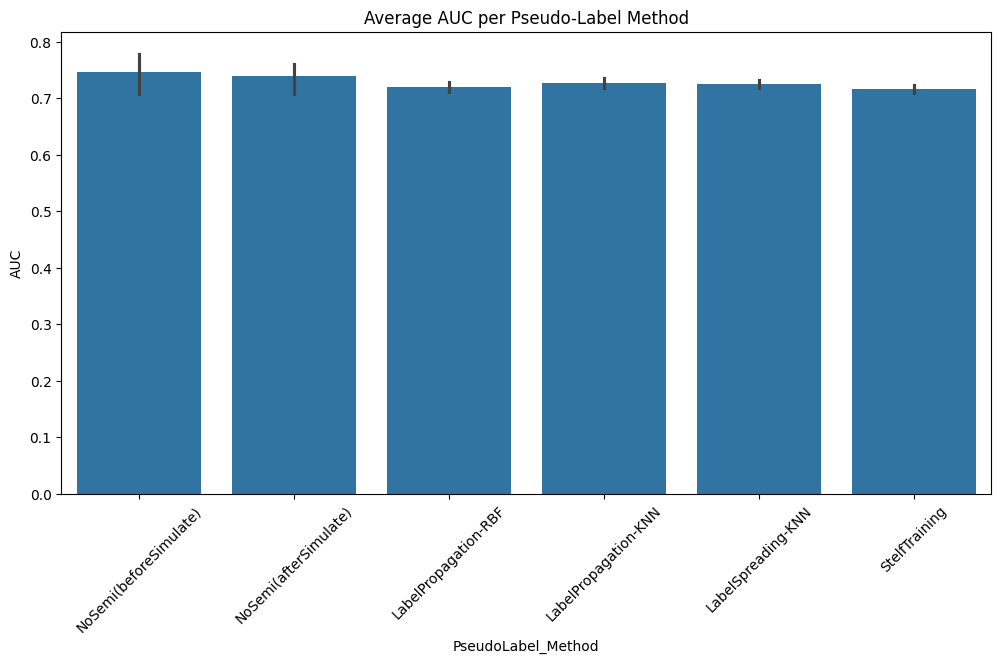

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    x="PseudoLabel_Method",
    y="AUC",
    data=df_results,
    estimator="mean"
)
plt.title("Average AUC per Pseudo-Label Method")
plt.xticks(rotation=45)
plt.show()


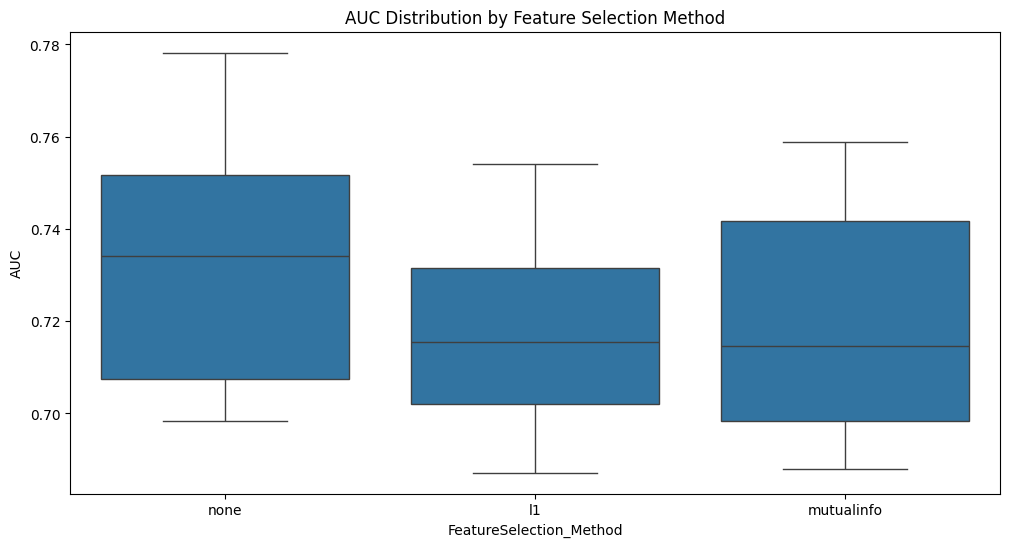

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x="FeatureSelection_Method",
    y="AUC",
    data=df_results
)
plt.title("AUC Distribution by Feature Selection Method")
plt.show()


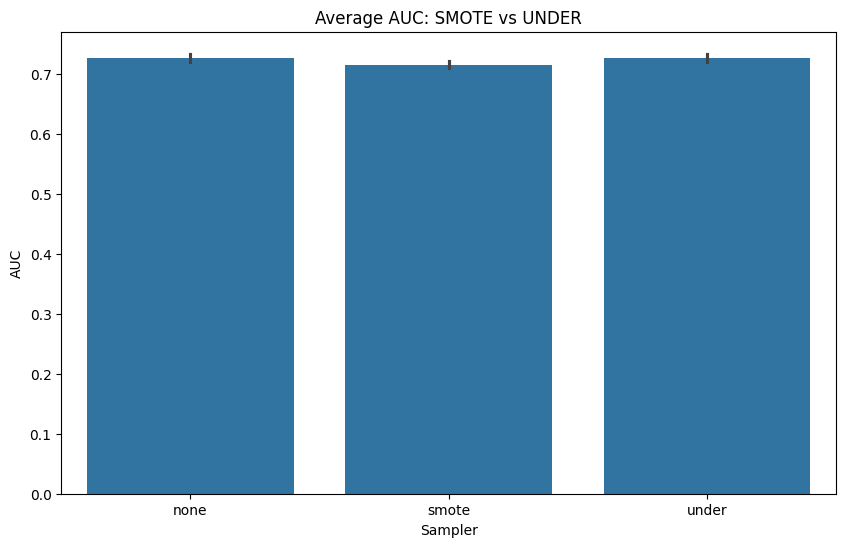

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Sampler",
    y="AUC",
    data=df_results,
    estimator="mean"
)
plt.title("Average AUC: SMOTE vs UNDER")
plt.show()


In [ ]:
best_row = df_sorted_auc.iloc[:5]
print("\nTop 3 model configuration:")
display(best_row)



Top 3 model configuration:


,PseudoLabel_Method,FeatureSelection_Method,Sampler,Model,Accuracy,F1,Precision,Recall,AUC
2,NoSemi(beforeSimulate),none,none,XGBoost,0.817500,0.466634,0.659780,0.360965,0.778235
41,LabelPropagation-KNN,none,none,XGBoost,0.814333,0.475518,0.633626,0.380558,0.761964
5,NoSemi(afterSimulate),none,none,XGBoost,0.812500,0.461465,0.632546,0.363225,0.761450
38,LabelPropagation-KNN,none,under,XGBoost,0.796667,0.532925,0.541634,0.524491,0.759072
59,LabelPropagation-KNN,mutualinfo,none,XGBoost,0.812667,0.467299,0.629630,0.371515,0.758829


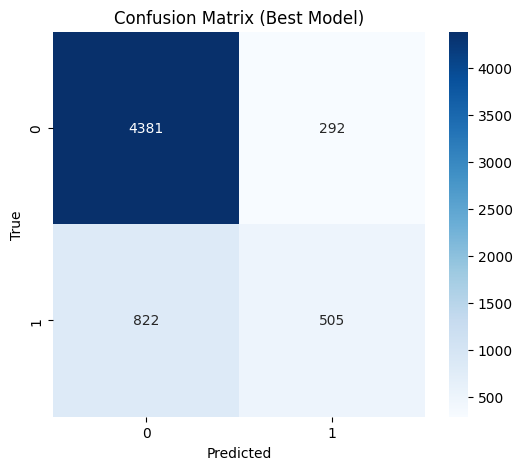

In [ ]:
best_row = df_sorted_auc.iloc[1]

pseudo = best_row["PseudoLabel_Method"]
fs     = best_row["FeatureSelection_Method"]
sampler = best_row["Sampler"]
model_name = best_row["Model"]
best_file = f"step6_{pseudo}_{fs}_{sampler}.csv"
df_best = pd.read_csv(os.path.join(SAVE_DIR, best_file))

X_best = df_best.drop("Y", axis=1)
y_best = df_best["Y"]

X_test_fs = X_test[X_best.columns]

# supervised models
supervised_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
    ),
}

best_model = supervised_models[model_name]
best_model.fit(X_best, y_best)

y_pred = best_model.predict(X_test_fs)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

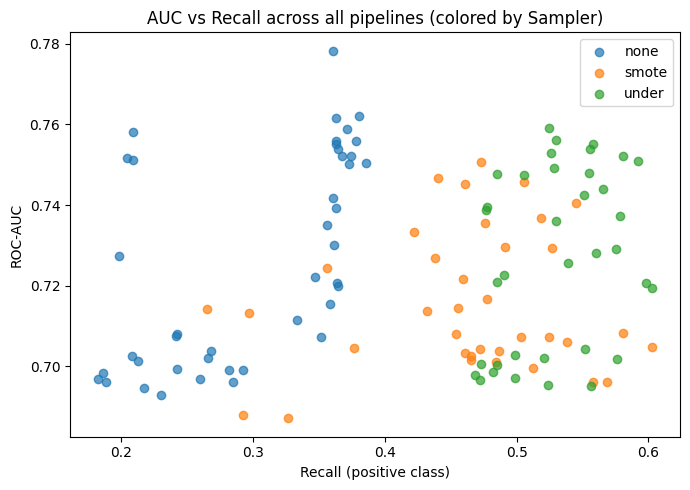

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("step7_model_results.csv")

plt.figure(figsize=(7,5))
for name, g in df.groupby("Sampler"):
    plt.scatter(g["Recall"], g["AUC"], label=name, alpha=0.7)

plt.xlabel("Recall (positive class)")
plt.ylabel("ROC-AUC")
plt.title("AUC vs Recall across all pipelines (colored by Sampler)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_auc_vs_recall_by_sampler.png", dpi=300)
plt.show()


In [5]:
import pandas as pd

df = pd.read_csv("step7_model_results.csv")

cands = []
keys = ["ssl", "pseudo", "label", "method", "algo", "stage"]
for c in df.columns:
    if any(k in c.lower() for k in keys):
        cands.append(c)

print("All columns:", df.columns.tolist())
print("Candidate columns:", cands)



All columns: ['PseudoLabel_Method', 'FeatureSelection_Method', 'Sampler', 'Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
Candidate columns: ['PseudoLabel_Method', 'FeatureSelection_Method']


Unique SSL methods: ['LabelPropagation-KNN', 'LabelPropagation-RBF', 'LabelSpreading-KNN', 'NoSemi(afterSimulate)', 'NoSemi(beforeSimulate)', 'StelfTraining']


/tmp/ipython-input-1092518537.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


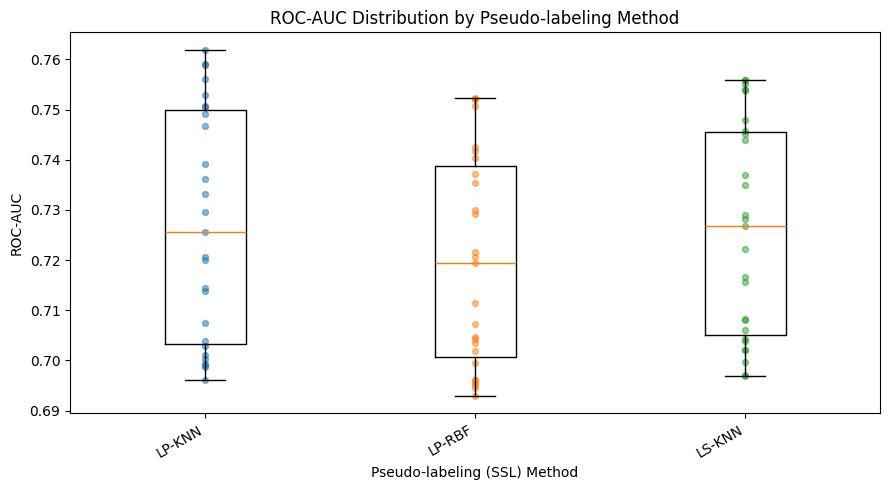

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("step7_model_results.csv")

ssl_col = "PseudoLabel_Method"
auc_col = "AUC"

# ⭐ 1️⃣ 显示名映射（只影响图，不影响数据）
rename_map = {
    "LabelPropagation-KNN": "LP-KNN",
    "LabelPropagation-RBF": "LP-RBF",
    "LabelSpreading-KNN": "LS-KNN",
    "SelfTraining": "Self-Training",
    "NoSemi(beforeSimulate)": "Supervised (30%)",
    "NoSemi(afterSimulate)": "Supervised (30%, aug)"
}

# ⭐ 2️⃣ 你论文中想展示的顺序（用真实列名！）
preferred_order = [
    "LabelPropagation-KNN",
    "LabelPropagation-RBF",
    "LabelSpreading-KNN",
    "SelfTraining"
]

print("Unique SSL methods:", sorted(df[ssl_col].unique().tolist()))

order = [m for m in preferred_order if m in set(df[ssl_col])]
if not order:
    order = sorted(df[ssl_col].unique().tolist())

# 数据
data = [
    df.loc[df[ssl_col] == m, auc_col].dropna().values
    for m in order
]

# ⭐ 3️⃣ 用“缩写名”作为 labels
labels = [rename_map.get(m, m) for m in order]

plt.figure(figsize=(9,5))
plt.boxplot(data, labels=labels, showfliers=False)

# 叠加散点
for i, m in enumerate(order, start=1):
    y = df.loc[df[ssl_col] == m, auc_col].dropna().values
    x = [i] * len(y)
    plt.scatter(x, y, alpha=0.5, s=18)

# ⭐ 4️⃣ 关键：旋转横轴
plt.xticks(rotation=30, ha="right")

plt.xlabel("Pseudo-labeling (SSL) Method")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Distribution by Pseudo-labeling Method")
plt.tight_layout()
plt.savefig("fig_auc_by_ssl_boxplot.png", dpi=300)
plt.show()
